 # 🧠 Biomedical Image Analysis: MRI Segmentation

## 📌 Objective

### This project aims to analyze cardiac MRI images and extract the left ventricle using image processing techniques.
------------------------------------------





### Let's import one sample 

You may refer to next source to download sample with number SCD2001_MR_117:

https://www.kaggle.com/datasets/salikhussaini49/sunnybrook-cardiac-mri

In [ ]:
# Import ImageIO
import imageio

# Load "chest-220.dcm"
im = imageio.imread("SCD2001_MR_117.dcm")

# Print image attributes
print('Image type:', type(im))
print('Shape of image array:', im.shape)

Image type: <class 'imageio.core.util.Array'>
Shape of image array: (256, 256)


### 📷 Visualizing the MRI Image
We display the MRI scan to understand its structure before processing.

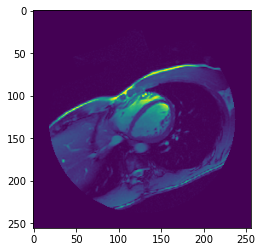

In [ ]:
import imageio
import matplotlib.pyplot as plt

# Read in "chest-220.dcm"
im = imageio.imread("SCD2001_MR_117.dcm")
plt.imshow(im)

### 🖤 Displaying the Image in Grayscale
The MRI image is visualized using a grayscale colormap to highlight intensity variations, which are essential for medical image analysis.

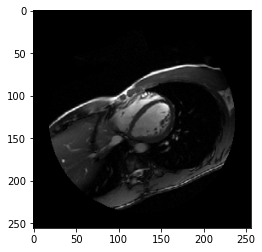

In [ ]:
plt.imshow(im, cmap='gray')

### A colorbar was added to the plot for better visualization

Data type: int16
Min. value: 0
Max value: 255


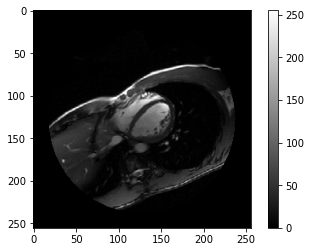

In [ ]:
import imageio
import numpy as np
import matplotlib.pyplot as plt

# Load the hand radiograph

print('Data type:', im.dtype)
print('Min. value:', im.min())
print('Max value:', im.max())

# Plot the grayscale image
plt.imshow(im, cmap='gray', vmin=0, vmax=255)
plt.colorbar()


### Apply rotation to the image/plot


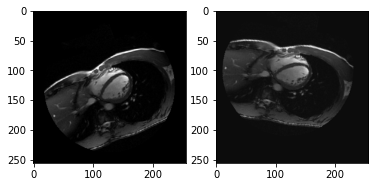

In [ ]:
import scipy.ndimage as ndi

xfm = ndi.shift(im, shift=(-20,-20))

# Rotate the shifted image
xfm = ndi.rotate(xfm, angle=-30, reshape=False)

# Plot the original and rotated images
fig, axes = plt.subplots(1, 2)
axes[0].imshow(im, cmap='gray')
axes[1].imshow(xfm ,cmap='gray')


### A histogram was generated


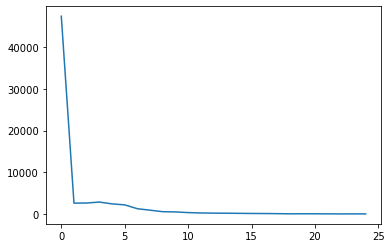

In [ ]:
import scipy.ndimage as ndi 

# Create a histogram, binned at each possible value
hist = ndi.histogram(im, min=0, max=250, bins=25)




plt.plot(hist, label='Histogram')



### A skin mask was created based on intensity values


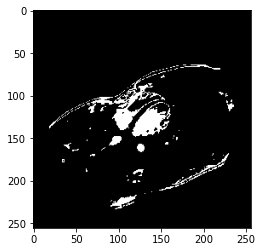

In [ ]:

mask_skin = (im>=70) & (im<145)

# Plot the skin masks

plt.imshow(mask_skin, cmap='gray')



### Show the selected skin region  



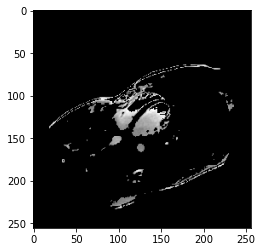

In [ ]:
im_skin = np.where(mask_skin, im, 0)
plt.imshow(im_skin, cmap='gray')

### We improved the mask using dilation and closing operations


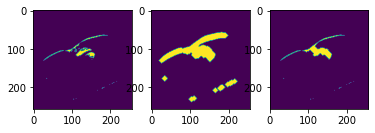

In [ ]:


mask_dilate = ndi.binary_dilation (im_skin, iterations=7)
mask_closed = ndi.binary_closing (im_skin, iterations=7)

# Plot masked images
fig, axes = plt.subplots(1,3)
axes[0].imshow(im_skin)
axes[1].imshow(mask_dilate)
axes[2].imshow(mask_closed)


###  result of running mask

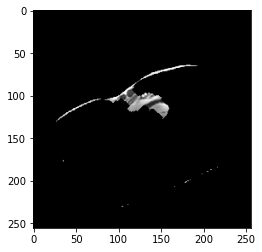

In [ ]:
im_bone = np.where(mask_closed, im, 0)
plt.imshow(im_bone,cmap='gray')

### Vertical edges were detected using a convolution filter

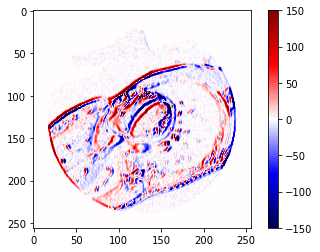

In [ ]:
# Set weights to detect vertical edges
weights = [[+1, 0, -1], [+1, 0, -1], [+1, 0, -1]]

# Convolve "im" with filter weights
edges = ndi.convolve(im, weights)

# Draw the image in color
plt.imshow(edges, cmap='seismic', vmin=-150, vmax=150)
plt.colorbar()

## The image was segmented by thresholding and morphological processing
Connected components were identified and labeled

Num. Labels: 26


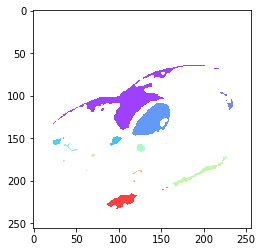

In [ ]:
# Smooth intensity values
im_filt = ndi.median_filter(im, size=3)

# Select high-intensity pixels
mask_start = np.where(im_filt>60, 1, 0)
mask = ndi.binary_closing(mask_start)

# Label the objects in "mask"
labels, nlabels = ndi.label(mask)
print('Num. Labels:',nlabels)

# Create a `labels` overlay
overlay = np.where(labels>0, labels, np.nan)

# Use imshow to plot the overlay
plt.imshow(overlay, cmap='rainbow', alpha=0.75)


### A specific object (left ventricle) was selected from the labeled image
Region extraction was performed using connected component labeling

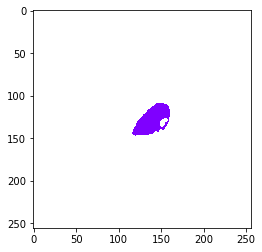

In [ ]:
labels, nlabels = ndi.label(mask)

# Select left ventricle pixels
lv_val = labels[128, 128]
lv_mask = np.where(labels == lv_val, 1, np.nan)

# Overlay selected label
plt.imshow(lv_mask, cmap='rainbow')
plt.show()

### The left ventricle region was extracted using connected component analysis
A bounding box was used to crop the region of interest

Number of objects: 1
Indices for first box: (slice(107, 149, None), slice(116, 162, None))


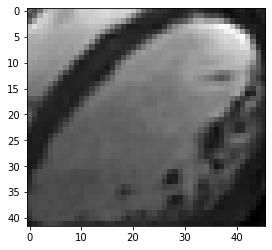

In [ ]:
# Create left ventricle mask
labels, nlabels = ndi.label(mask)
lv_val = labels[128, 128]
lv_mask = np.where(labels == lv_val, 1, 0)

# Find bounding box of left ventricle
bboxes = ndi.find_objects(lv_mask)
print('Number of objects:', len(bboxes))
print('Indices for first box:', bboxes[0])

# Crop to the left ventricle (index 0)
im_lv = im[bboxes[0]]

# Plot the cropped image
plt.imshow(im_lv,cmap='gray')


## 🎯 Results

- Successfully segmented the left ventricle
- Applied filtering and morphological operations
- Detected regions of interest using labeling

## 📌 Conclusion

This project demonstrates how basic image processing techniques can be used to analyze medical images and extract meaningful regions.